# Convertible-Bonds — equity upside with a bond floor? 🪢
### Do convertibles really catch the rally but cushion the crash?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Equity_upside_bond_downside%3F: Busted](https://img.shields.io/badge/Equity_upside_bond_downside%3F-Busted-8b949e?style=flat-square)

Convertible bonds are sold as the best of both worlds: a corporate bond with a built-in stock option, so you *convert* and ride the rally if the company soars, but you collect the coupon and lean on the bond floor if it sinks. The picture is a hockey-stick — a **convex** payoff. This notebook asks whether the most popular convertibles ETF (**CWB**) actually delivers that curve, or whether it's just a plain stock/bond mix wearing a fancier name.

> 📓 **This is the plain-language layer.** Want the regressions, the bootstrap confidence intervals and the capacity math? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

from convertible_bonds import data, strategy as st


def load_tape():
    """Real CWB/SPY/AGG/SHY frame if reachable, else the deterministic synthetic tape."""
    try:
        frame = data.load_real(end="2026-05-31")
        if len(frame) > 1000 and {"CWB", "SPY", "AGG", "SHY"}.issubset(frame.columns):
            return frame, "real"
    except Exception as e:
        print("real load failed -> synthetic:", type(e).__name__)
    frame, _ = data.synthetic_convex(n_days=4000, gamma=0.6, seed=339)
    return frame, "synthetic"


FRAME, TAPE = load_tape()
# Column map: real tape uses tickers; synthetic uses IDX/BND/CVT.
if TAPE == "real":
    CVT, IDX, BND, CASH = "CWB", "SPY", "AGG", "SHY"
    BANNER = "REAL tape — CWB / SPY / AGG / SHY, total return"
else:
    CVT, IDX, BND, CASH = "CVT", "IDX", "BND", None
    BANNER = "SYNTHETIC tape (offline fallback — a PLANTED-convex control, NOT real CWB)"
RETS = st.to_returns(FRAME)
RF = RETS[CASH] if CASH else None
print("tape in this run:", BANNER)
print("rows:", len(FRAME), " range:", FRAME.index[0].date(), "->", FRAME.index[-1].date())


tape in this run: REAL tape — CWB / SPY / AGG / SHY, total return
rows: 4307  range: 2009-04-16 -> 2026-05-29


## The answer first 🎯

*(Headline numbers are the **real** CWB/SPY/AGG/SHY tape, 2009-04-16 → 2026-05-29, from [docs/results.md](../docs/results.md). The executed cells below run on whichever tape this machine has — they banner which.)*

| Question | Plain answer |
|---|---|
| Is the payoff actually *convex* (a hockey-stick)? | **No.** The curvature we measure has the **wrong sign** (slightly *concave*), and it's significant (*t* = -2.96) — the opposite of the brochure. |
| Does it catch more of the rally than the fall? | **Barely.** It keeps ~66% of up days and ~64% of down days — almost symmetric, not the promised asymmetry. |
| Can you replicate it with a plain stock/bond mix? | **Yes — and cheaper.** A ~63% stocks / 37% bonds blend matched its risk and *edged it* on Sharpe, at a fraction of the fee. |

> So a convertibles ETF behaves like **a stock/bond blend with an extra fee**. The convexity that justifies the wrapper does not show up in the tape.

## 1 · The claim

The convertibles pitch, at full strength:

> *A convertible bond gives you **equity upside with bond downside**. If the stock takes off, your bond converts into shares and you ride it up. If the stock tanks, you still hold a bond paying a coupon, so a **bond floor** catches you. It's a one-way bet — heads you win like a stock, tails you lose like a bond.*

Drawn as a chart, that's a **convex** payoff: a curve that bends *up*, capturing more of the gains than the losses. Convexity is the whole product.

## 2 · So what?

If convexity is real and free, convertibles are a genuine free lunch — more upside per unit of downside than any plain mix of the same stock and bond. Issuers love them (cheaper coupons), and a whole fund category is sold on the curve. But there's a catch built into the idea: an *option* is never free. The convexity is *paid for* — in a lower coupon, in credit risk, in a fee. The question is whether what you get back is curvature you couldn't have bought more cheaply by just holding some stock and some bonds yourself.

## 3 · How would we even know?

Two pictures settle it:

1. **Plot every day:** the stock market's move across, the convertible's move up. A *convex* payoff bends upward — a smile. A plain mix is a straight line. We literally fit the curve and read its bend.
2. **Build the plain mix it claims to beat:** some stocks, some bonds, dialled to the convertible's risk. If the convertible can't out-curve *and* out-earn that blend, the wrapper added nothing.

**What would make us say 'mirage':** if the fitted curve doesn't bend up (no convexity), if up-capture isn't clearly above down-capture, and if a cheap stock/bond blend keeps pace. (It's all three.)

## 4 · The teardown — let's actually look

### Does the payoff bend upward?

Each dot is one day: the stock market across, the convertible up. If the payoff were convex, a fitted curve would **bend up** — steeper on the right (rallies) than the left (selloffs). Let's fit it and see which way it bends.

REAL tape — CWB / SPY / AGG / SHY, total return
fitted payoff:  r_CWB = a + b*r_SPY + gamma*up^2
  slope  b     = 0.658
  curvature g  = -1.897   (>0 = convex smile, <0 = concave frown)
  robust t(g)  = -2.96


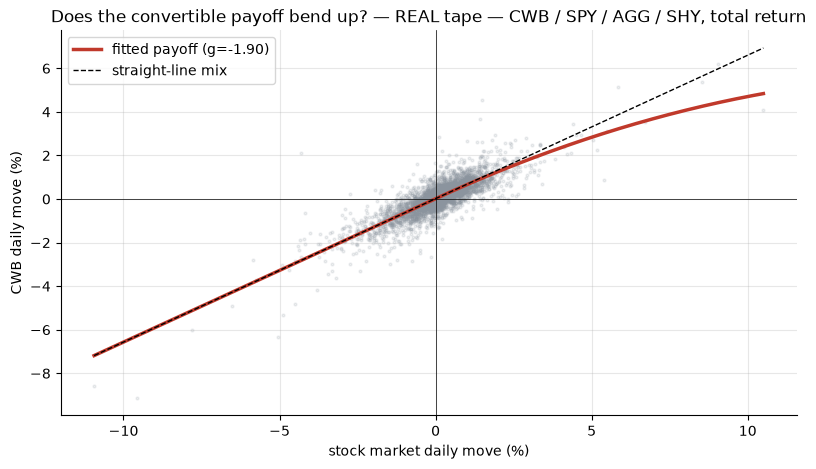

In [2]:
reg = st.convexity_regression(RETS, CVT, IDX)
print(BANNER)
print(f'fitted payoff:  r_{CVT} = a + b*r_{IDX} + gamma*up^2')
print(f'  slope  b     = {reg["beta"]:.3f}')
print(f'  curvature g  = {reg["gamma"]:.3f}   (>0 = convex smile, <0 = concave frown)')
print(f'  robust t(g)  = {reg["t_gamma"]:.2f}')

x = RETS[IDX].to_numpy(); y = RETS[CVT].to_numpy()
grid = np.linspace(x.min(), x.max(), 200)
fit = reg['alpha'] + reg['beta']*grid + reg['gamma']*np.maximum(grid,0)**2
fig, ax = plt.subplots()
ax.scatter(x*100, y*100, s=4, alpha=.15, color=GREY)
ax.plot(grid*100, fit*100, color=(GREEN if reg['gamma']>0 else RED), lw=2.5,
        label=f'fitted payoff (g={reg["gamma"]:.2f})')
ax.plot(grid*100, (reg['alpha']+reg['beta']*grid)*100, '--', color='k', lw=1,
        label='straight-line mix')
ax.axhline(0, color='k', lw=.5); ax.axvline(0, color='k', lw=.5)
ax.set_xlabel('stock market daily move (%)'); ax.set_ylabel(f'{CVT} daily move (%)')
ax.set_title(f'Does the convertible payoff bend up? — {BANNER}'); ax.legend()
plt.show()

> 🔬 **For the quants:** the bend is the coefficient on `up² = max(r,0)²`. On the **real** CWB tape it comes out *negative* (g = -1.897, *t* = -2.96) — a slight **frown**, the opposite of the advertised smile. The synthetic fallback plants a real smile so you can see what convexity *would* look like.

### Does it keep more of the rally than the fall?

The other way to read convexity: on days the market rose, how much did the convertible capture — versus on days it fell? Convexity means **up-capture well above down-capture**.

up-capture   : 0.664
down-capture : 0.645
asymmetry    : +0.019  (convexity wants this clearly > 0)


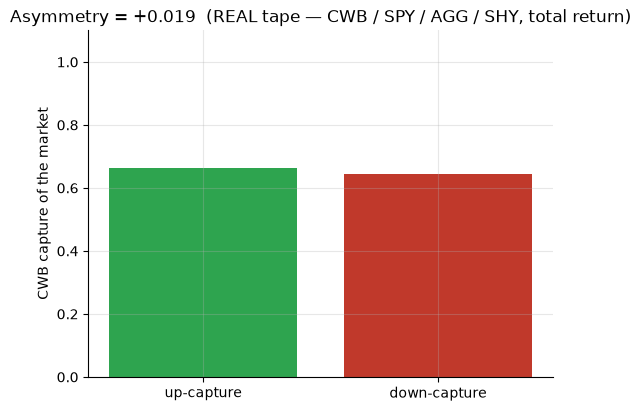

In [3]:
cap = st.capture_ratios(RETS, CVT, IDX)
print(f'up-capture   : {cap["up_capture"]:.3f}')
print(f'down-capture : {cap["down_capture"]:.3f}')
print(f'asymmetry    : {cap["asymmetry"]:+.3f}  (convexity wants this clearly > 0)')

fig, ax = plt.subplots(figsize=(6,4.5))
ax.bar(['up-capture','down-capture'], [cap['up_capture'], cap['down_capture']],
       color=[GREEN, RED])
ax.set_ylabel(f'{CVT} capture of the market'); ax.set_ylim(0, 1.1)
ax.set_title(f'Asymmetry = {cap["asymmetry"]:+.3f}  ({BANNER})')
plt.show()

### Can a plain stock/bond blend keep up?

Now the head-to-head: build a simple stocks+bonds mix dialled to the convertible's equity exposure, rebalanced yearly, and race the growth of $1.

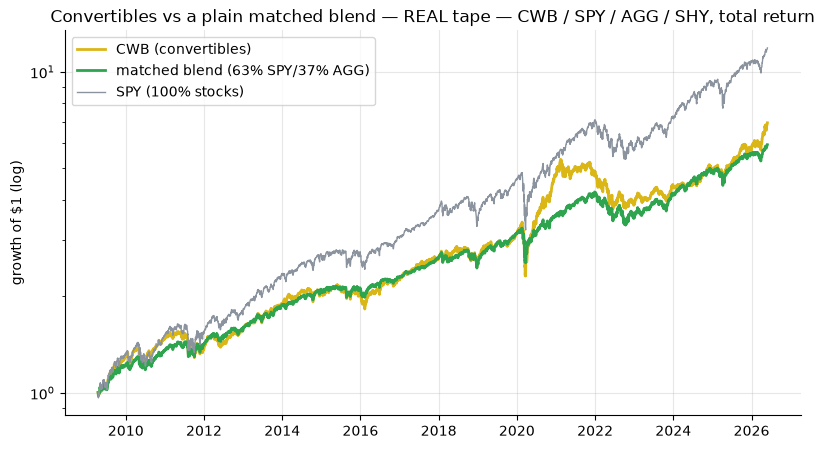

CWB      CAGR=+12.0%  vol=13.1%  Sharpe(xs)=0.817  maxDD=-32.1%
blend    CAGR=+11.0%  vol=10.9%  Sharpe(xs)=0.879  maxDD=-22.0%
SPY      CAGR=+15.6%  vol=17.2%  Sharpe(xs)=0.838  maxDD=-33.7%


In [4]:
beta = st.beta_to(RETS, CVT, IDX)
w = float(np.clip(beta, 0, 1))
blend = st.matched_blend(RETS, IDX, BND, w_stock=w, rebalance='annual', cost_bps=2.0)
eq_cvt = (1+RETS[CVT]).cumprod(); eq_bl = (1+blend).cumprod(); eq_idx = (1+RETS[IDX]).cumprod()
fig, ax = plt.subplots()
ax.plot(eq_cvt, color=AMBER, lw=2, label=f'{CVT} (convertibles)')
ax.plot(eq_bl, color=GREEN, lw=2, label=f'matched blend ({w:.0%} {IDX}/{1-w:.0%} {BND})')
ax.plot(eq_idx, color=GREY, lw=1, label=f'{IDX} (100% stocks)')
ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)')
ax.set_title(f'Convertibles vs a plain matched blend — {BANNER}'); ax.legend()
plt.show()
for nm, s in [(CVT, RETS[CVT]), ('blend', blend), (IDX, RETS[IDX])]:
    d = st.stats(s, rf=RF)
    print(f'{nm:8s} CAGR={d["cagr"]:+.1%}  vol={d["vol"]:.1%}  Sharpe(xs)={d["sharpe"]:.3f}  maxDD={d["max_dd"]:.1%}')

## 5 · The verdict

- **Convexity — not there.** The fitted payoff doesn't bend up; on the real CWB tape it bends slightly *down* (*t* = -2.96). Up-capture (66%) barely beats down-capture (64%). → **Signal: None.**
- **A plain blend matched it — cheaper.** A 63%/37% stock/bond mix edged CWB on Sharpe (0.879 vs 0.817) at a smaller drawdown, with no 0.40%/yr fee. → **Tradability: Mirage.**
- **The bond floor failed when it mattered.** In the worst month (March 2020) CWB fell **-13.1%** — *more* than the stock market (-12.5%) and far more than the blend (-7.7%). → the *'equity upside, bond downside'* story is **Busted**.

## 6 · Could you actually trade it?

You absolutely *can* buy CWB — it's a liquid ETF. The problem isn't access, it's that you're paying ~0.40%/yr (plus the convertibles' embedded option cost and credit risk) for a payoff you could **replicate with two of the cheapest funds on earth** (a broad stock ETF + a broad bond ETF) at near-zero fee — and the replica matched the risk-adjusted return. There's no curvature to pay up for, so the fee is dead weight.

## 7 · Going further 🚪

- **Single-name converts vs the ETF.** A diversified ETF blends balanced, busted and equity-like converts into mush; an individual deep-in-the-money convertible *is* near-linear-to-equity, while an out-of-the-money one is near-pure-bond. Does convexity live at the single-name level even if the basket washes it out?
- **Other convertibles funds (ICVT, FCVT).** Same test, different wrappers.
- **Regime conditioning.** Does the curve bend up only in low-vol bull regimes?

Fork the notebook, swap the ticker in `data.load_real`, and re-run.